# 06 - Weight Initializations, Residual Connections & Deep CNNs

This notebook investigates **weight initializations for 2D Convolutions** and **Residual (Skip) Connections** in deep CNN architectures:

---

## Topics Covered:

1. **Weight Initializations for Conv2d**:
   - `torch.nn.init.kaiming_normal_` (He Init) tailored for Conv + ReLU (fan_in vs fan_out mode).
   - `torch.nn.init.xavier_normal_` (Glorot Init).
2. **Residual Connections (ResNet Blocks)**:
   - Mechanics of skip connections: $y = \mathcal{F}(x) + x$.
   - Why residual connections prevent vanishing gradients in deep CNNs ($50+$ layers).
3. **Gradient Dynamics in Deep CNNs**:
   - Tracking conv layer gradient norms in standard vs residual CNN architectures.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Conv2d Initializations (`torch.nn.init`)

Initializing 2D convolutional filter weights:

- `kaiming_normal_(w, mode='fan_in', nonlinearity='relu')`: Preserves variance in forward pass.
- `kaiming_normal_(w, mode='fan_out', nonlinearity='relu')`: Preserves variance in backward pass.


In [2]:
def init_conv_kaiming(m):
    if isinstance(m, nn.Conv2d):
        init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0.0)

def init_conv_xavier(m):
    if isinstance(m, nn.Conv2d):
        init.xavier_normal_(m.weight)
        if m.bias is not None:
            init.constant_(m.bias, 0.0)

# Apply to sample Conv layer
sample_conv = nn.Conv2d(64, 128, 3, padding=1)
init_conv_kaiming(sample_conv)
print("Kaiming Normal Conv Weight Mean:", sample_conv.weight.mean().item())
print("Kaiming Normal Conv Weight Std: ", sample_conv.weight.std().item())


Kaiming Normal Conv Weight Mean: 1.2130120921938214e-05
Kaiming Normal Conv Weight Std:  0.04182157665491104


## 2. Building a ResNet Residual Block in PyTorch

A Residual Block computes $y = \text{ReLU}(\mathcal{F}(x) + x)$. If dimensions change, a $1 \times 1$ shortcut projection is used for $x$.


In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection handling dimension matching
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        out += residual # Skip connection addition
        out = F.relu(out)
        return out

res_block = ResidualBlock(in_channels=32, out_channels=64, stride=2)
x_in = torch.randn(2, 32, 16, 16)
x_out = res_block(x_in)

print(f"Residual Block Input Shape:  {list(x_in.shape)}")
print(f"Residual Block Output Shape: {list(x_out.shape)}")


Residual Block Input Shape:  [2, 32, 16, 16]
Residual Block Output Shape: [2, 64, 8, 8]


## 3. Deep Plain CNN vs Deep ResNet Gradient Flow Comparison

We construct a 12-block Plain CNN vs a 12-block Residual CNN and track gradient magnitudes across early conv layers.


<>:39: SyntaxWarning: invalid escape sequence '\|'
<>:39: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_8895/453461702.py:39: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('Gradient Norm $\|\nabla W\|$')


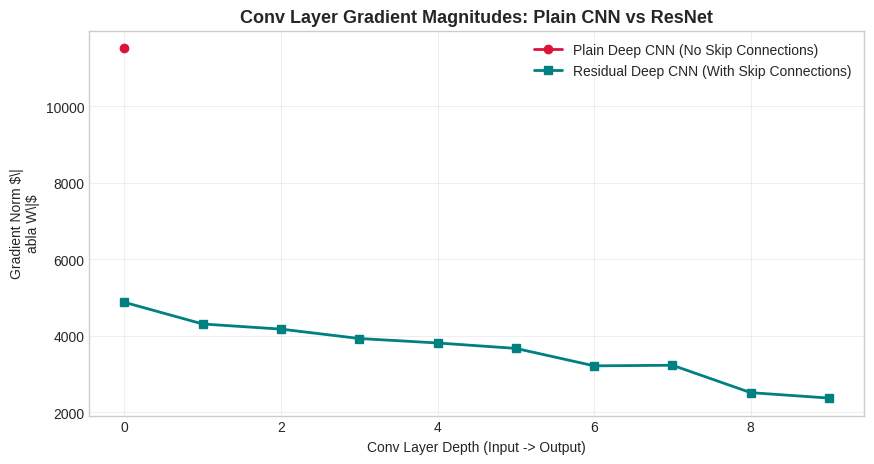

In [4]:
class PlainDeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU()] * 10
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class ResDeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([ResidualBlock(16, 16) for _ in range(5)])
    def forward(self, x):
        for b in self.blocks:
            x = b(x)
        return x

plain_model = PlainDeepCNN()
res_model = ResDeepCNN()

# Measure gradients
def get_grad_norms(model):
    x = torch.randn(8, 16, 14, 14)
    out = model(x).sum()
    out.backward()
    norms = []
    for m in model.modules():
        if isinstance(m, nn.Conv2d) and m.weight.grad is not None:
            norms.append(m.weight.grad.norm().item())
    return norms

plain_grads = get_grad_norms(plain_model)
res_grads = get_grad_norms(res_model)

plt.figure(figsize=(10, 5))
plt.plot(plain_grads, marker='o', label='Plain Deep CNN (No Skip Connections)', color='crimson', linewidth=2)
plt.plot(res_grads, marker='s', label='Residual Deep CNN (With Skip Connections)', color='teal', linewidth=2)
plt.title('Conv Layer Gradient Magnitudes: Plain CNN vs ResNet', fontsize=13, fontweight='bold')
plt.xlabel('Conv Layer Depth (Input -> Output)')
plt.ylabel('Gradient Norm $\|\nabla W\|$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
